In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('data/train-test.csv')
val_df = pd.read_csv('data/validation.csv')
dec_df = pd.read_csv('data/december-chart-inputs.csv')

In [74]:
train_df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,year,month,day,dayofweek,quarter,is_weekend
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,48000,47626.000000,48000.000000,48000.000000,48000.0,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,2025-05-31 19:53:29.399999,1.083387,2.062468,2373.980682,2025.0,5.505312,15.688542,3.003146,2.203250,0.282875
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000,2025.0,1.000000,1.000000,0.000000,1.000000,0.000000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,2025-03-18 00:00:00,0.949670,1.891030,1251.555000,2025.0,3.000000,8.000000,1.000000,1.000000,0.000000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000,2025.0,5.000000,16.000000,3.000000,2.000000,0.000000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,2025-08-15 00:00:00,1.219590,2.221685,3330.750000,2025.0,8.000000,23.000000,5.000000,3.000000,1.000000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000,2025.0,10.000000,31.000000,6.000000,4.000000,1.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,NaN,0.168091,0.291391,1486.493245,0.0,2.864084,8.837635,1.990637,0.979605,0.450401


In [75]:
val_df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,year,month,day,dayofweek,quarter,is_weekend
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11835.000000,12000,11751.000000,12000.000000,12000.0,12000.000000,12000.000000,12000.000000,12000.0,12000.000000
mean,35.574216,-90.724880,35.609538,-90.913530,1141.773100,30506.636248,2025-12-01 02:30:28.800000,0.926913,2.051334,2025.0,11.513667,15.694500,2.996083,4.0,0.297333
min,25.500000,-121.698490,25.500000,-121.698490,70.000000,-47500.000000,2025-11-01 00:00:00,0.723610,1.234760,2025.0,11.000000,1.000000,0.000000,4.0,0.000000
25%,31.986910,-97.226810,32.009290,-98.400590,556.100000,25493.000000,2025-11-16 00:00:00,0.863880,1.903467,2025.0,11.000000,8.000000,1.000000,4.0,0.000000
50%,35.294790,-87.528710,35.294790,-87.528710,953.600000,31193.000000,2025-12-01 00:00:00,0.922900,2.051230,2025.0,12.000000,16.000000,3.000000,4.0,0.000000
75%,39.411040,-82.783790,39.411040,-82.783790,1670.500000,36843.500000,2025-12-16 00:00:00,0.992355,2.200030,2025.0,12.000000,23.000000,5.000000,4.0,1.000000
max,44.302960,-69.500000,44.302960,-69.500000,3325.700000,47500.000000,2025-12-31 00:00:00,1.098950,2.896350,2025.0,12.000000,31.000000,6.000000,4.0,1.000000
std,4.366999,13.411638,4.351844,13.624744,732.333797,10572.590450,NaN,0.074109,0.219804,0.0,0.499834,8.847025,2.022352,0.0,0.457104


In [9]:
train_df.shape

(48000, 14)

In [3]:
print("Training Data Information (train-test.csv)")
print(train_df.info())

Training Data Information (train-test.csv)
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB
None


In [24]:
train_df = train_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
print(train_df.isna().sum())

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [39]:
train_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
train_df['weight'] = pd.to_numeric(train_df['weight'], errors='coerce')
train_df['market_index'] = pd.to_numeric(train_df['market_index'], errors='coerce')

In [48]:
print(train_df.loc[511, 'market_index'])
print(train_df.loc[911, 'weight'])


nan
nan


In [ ]:
# 1. Convert the date column to datetime format
# errors='coerce' turns any invalid or unparseable dates into NaT (Not a Time) safely
train_df['date'] = pd.to_datetime(train_df['date'], errors='coerce')

# 2. Extract useful temporal features for seasonality and trend understanding
train_df['year'] = train_df['date'].dt.year                  
train_df['month'] = train_df['date'].dt.month               
train_df['day'] = train_df['date'].dt.day                    
train_df['dayofweek'] = train_df['date'].dt.dayofweek        
train_df['quarter'] = train_df['date'].dt.quarter           
train_df['is_weekend'] = train_df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Optional: Drop the original date column if you won't use it directly in models, 
# or keep it if needed.
# df = df.drop(columns=['date'])

# Print info to verify the new features
print(train_df[['date', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend']].head())

        date  year  month  day  dayofweek  quarter  is_weekend
0 2025-01-01  2025      1    1          2        1           0
1 2025-01-01  2025      1    1          2        1           0
2 2025-01-01  2025      1    1          2        1           0
3 2025-01-01  2025      1    1          2        1           0
4 2025-01-01  2025      1    1          2        1           0


In [67]:
print("Train Data Columns")
print(train_df.columns)

Train Data Columns
Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate', 'year', 'month',
       'day', 'dayofweek', 'quarter', 'is_weekend'],
      dtype='str')


In [68]:
print("First 10 Rows of Training Data")
display(train_df.head(5))

First 10 Rows of Training Data


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,year,month,day,dayofweek,quarter,is_weekend
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,2025,1,1,2,1,0
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,2025,1,1,2,1,0
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,2025,1,1,2,1,0
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,2025,1,1,2,1,0
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,2025,1,1,2,1,0


In [26]:
print("Validation Data Columns")
print(val_df.columns)

Validation Data Columns
Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal'],
      dtype='str')


In [27]:
val_df.shape

(12000, 13)

In [28]:
print("Validation Data Information (validation.csv)")
print(val_df.info())

Validation Data Information (validation.csv)
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  str    
 1   pickup        12000 non-null  str    
 2   delivery      12000 non-null  str    
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  str    
 9   weight        11835 non-null  float64
 10  date          12000 non-null  str    
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), str(5)
memory usage: 1.2 MB
None


In [50]:
val_df = val_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
print(val_df.isna().sum())

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


In [53]:
print(val_df.loc[4, 'weight'])
print(val_df.loc[186, 'market_index'])


nan
nan


In [77]:
# 1. Convert the date column to datetime format
# errors='coerce' turns any invalid or unparseable dates into NaT (Not a Time) safely
val_df['date'] = pd.to_datetime(val_df['date'], errors='coerce')

# 2. Extract useful temporal features for seasonality and trend understanding
val_df['year'] = val_df['date'].dt.year                  
val_df['month'] = val_df['date'].dt.month               
val_df['day'] = val_df['date'].dt.day                    
val_df['dayofweek'] = val_df['date'].dt.dayofweek        
val_df['quarter'] = val_df['date'].dt.quarter           
val_df['is_weekend'] = val_df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Drop the original date column
df = df.drop(columns=['date'])

# Print info to verify the new features
print(val_df[['date', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend']].head())

        date  year  month  day  dayofweek  quarter  is_weekend
0 2025-11-01  2025     11    1          5        4           1
1 2025-11-01  2025     11    1          5        4           1
2 2025-11-01  2025     11    1          5        4           1
3 2025-11-01  2025     11    1          5        4           1
4 2025-11-01  2025     11    1          5        4           1


In [54]:
print("First 10 Rows of Validation Data")
display(val_df.head(10))

First 10 Rows of Validation Data


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541
5,TE-000006,Columbia,Fresno,34.63570,-83.28506,33.07921,-119.79528,2405.4,Dry Van,26124.0,2025-11-01,0.86615,2.19932
6,TE-000007,Raleigh,Phoenix,35.37376,-77.47605,28.75668,-115.87725,2646.5,Reefer,26069.0,2025-11-01,0.91528,2.24680
7,TE-000008,San Antonio,Detroit,29.50969,-98.40059,43.61923,-84.04517,1448.6,Dry Van,28194.0,2025-11-01,0.93007,2.20590
8,TE-000009,Lexington,Harrisburg,36.99152,-84.99876,39.71695,-78.12481,482.9,Dry Van,39674.0,2025-11-01,0.93645,2.00931
9,TE-000010,Norfolk,Columbia,37.12278,-75.87106,34.63570,-83.28506,534.4,Dry Van,22086.0,2025-11-01,0.88997,1.71182


In [70]:
# Set the visualization theme to look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Read the original data before any preprocessing
df = pd.read_csv('data/train-test.csv')

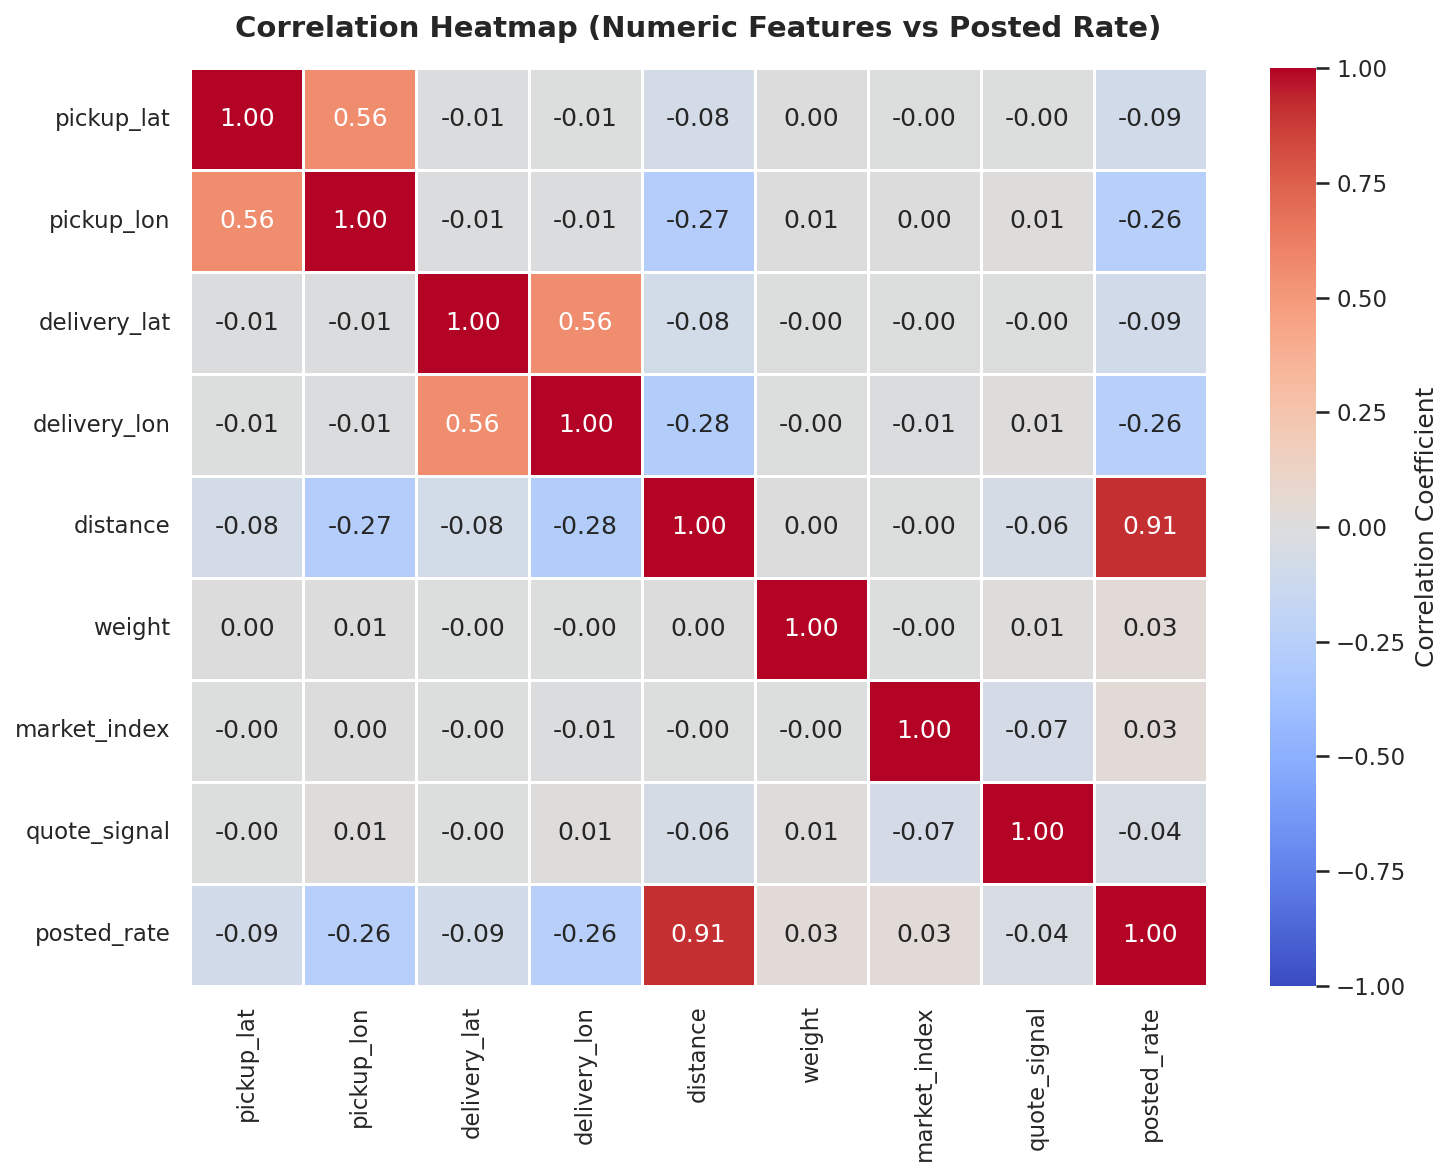

In [71]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8), dpi=150)

# Select numeric features only
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation Heatmap (Numeric Features vs Posted Rate)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

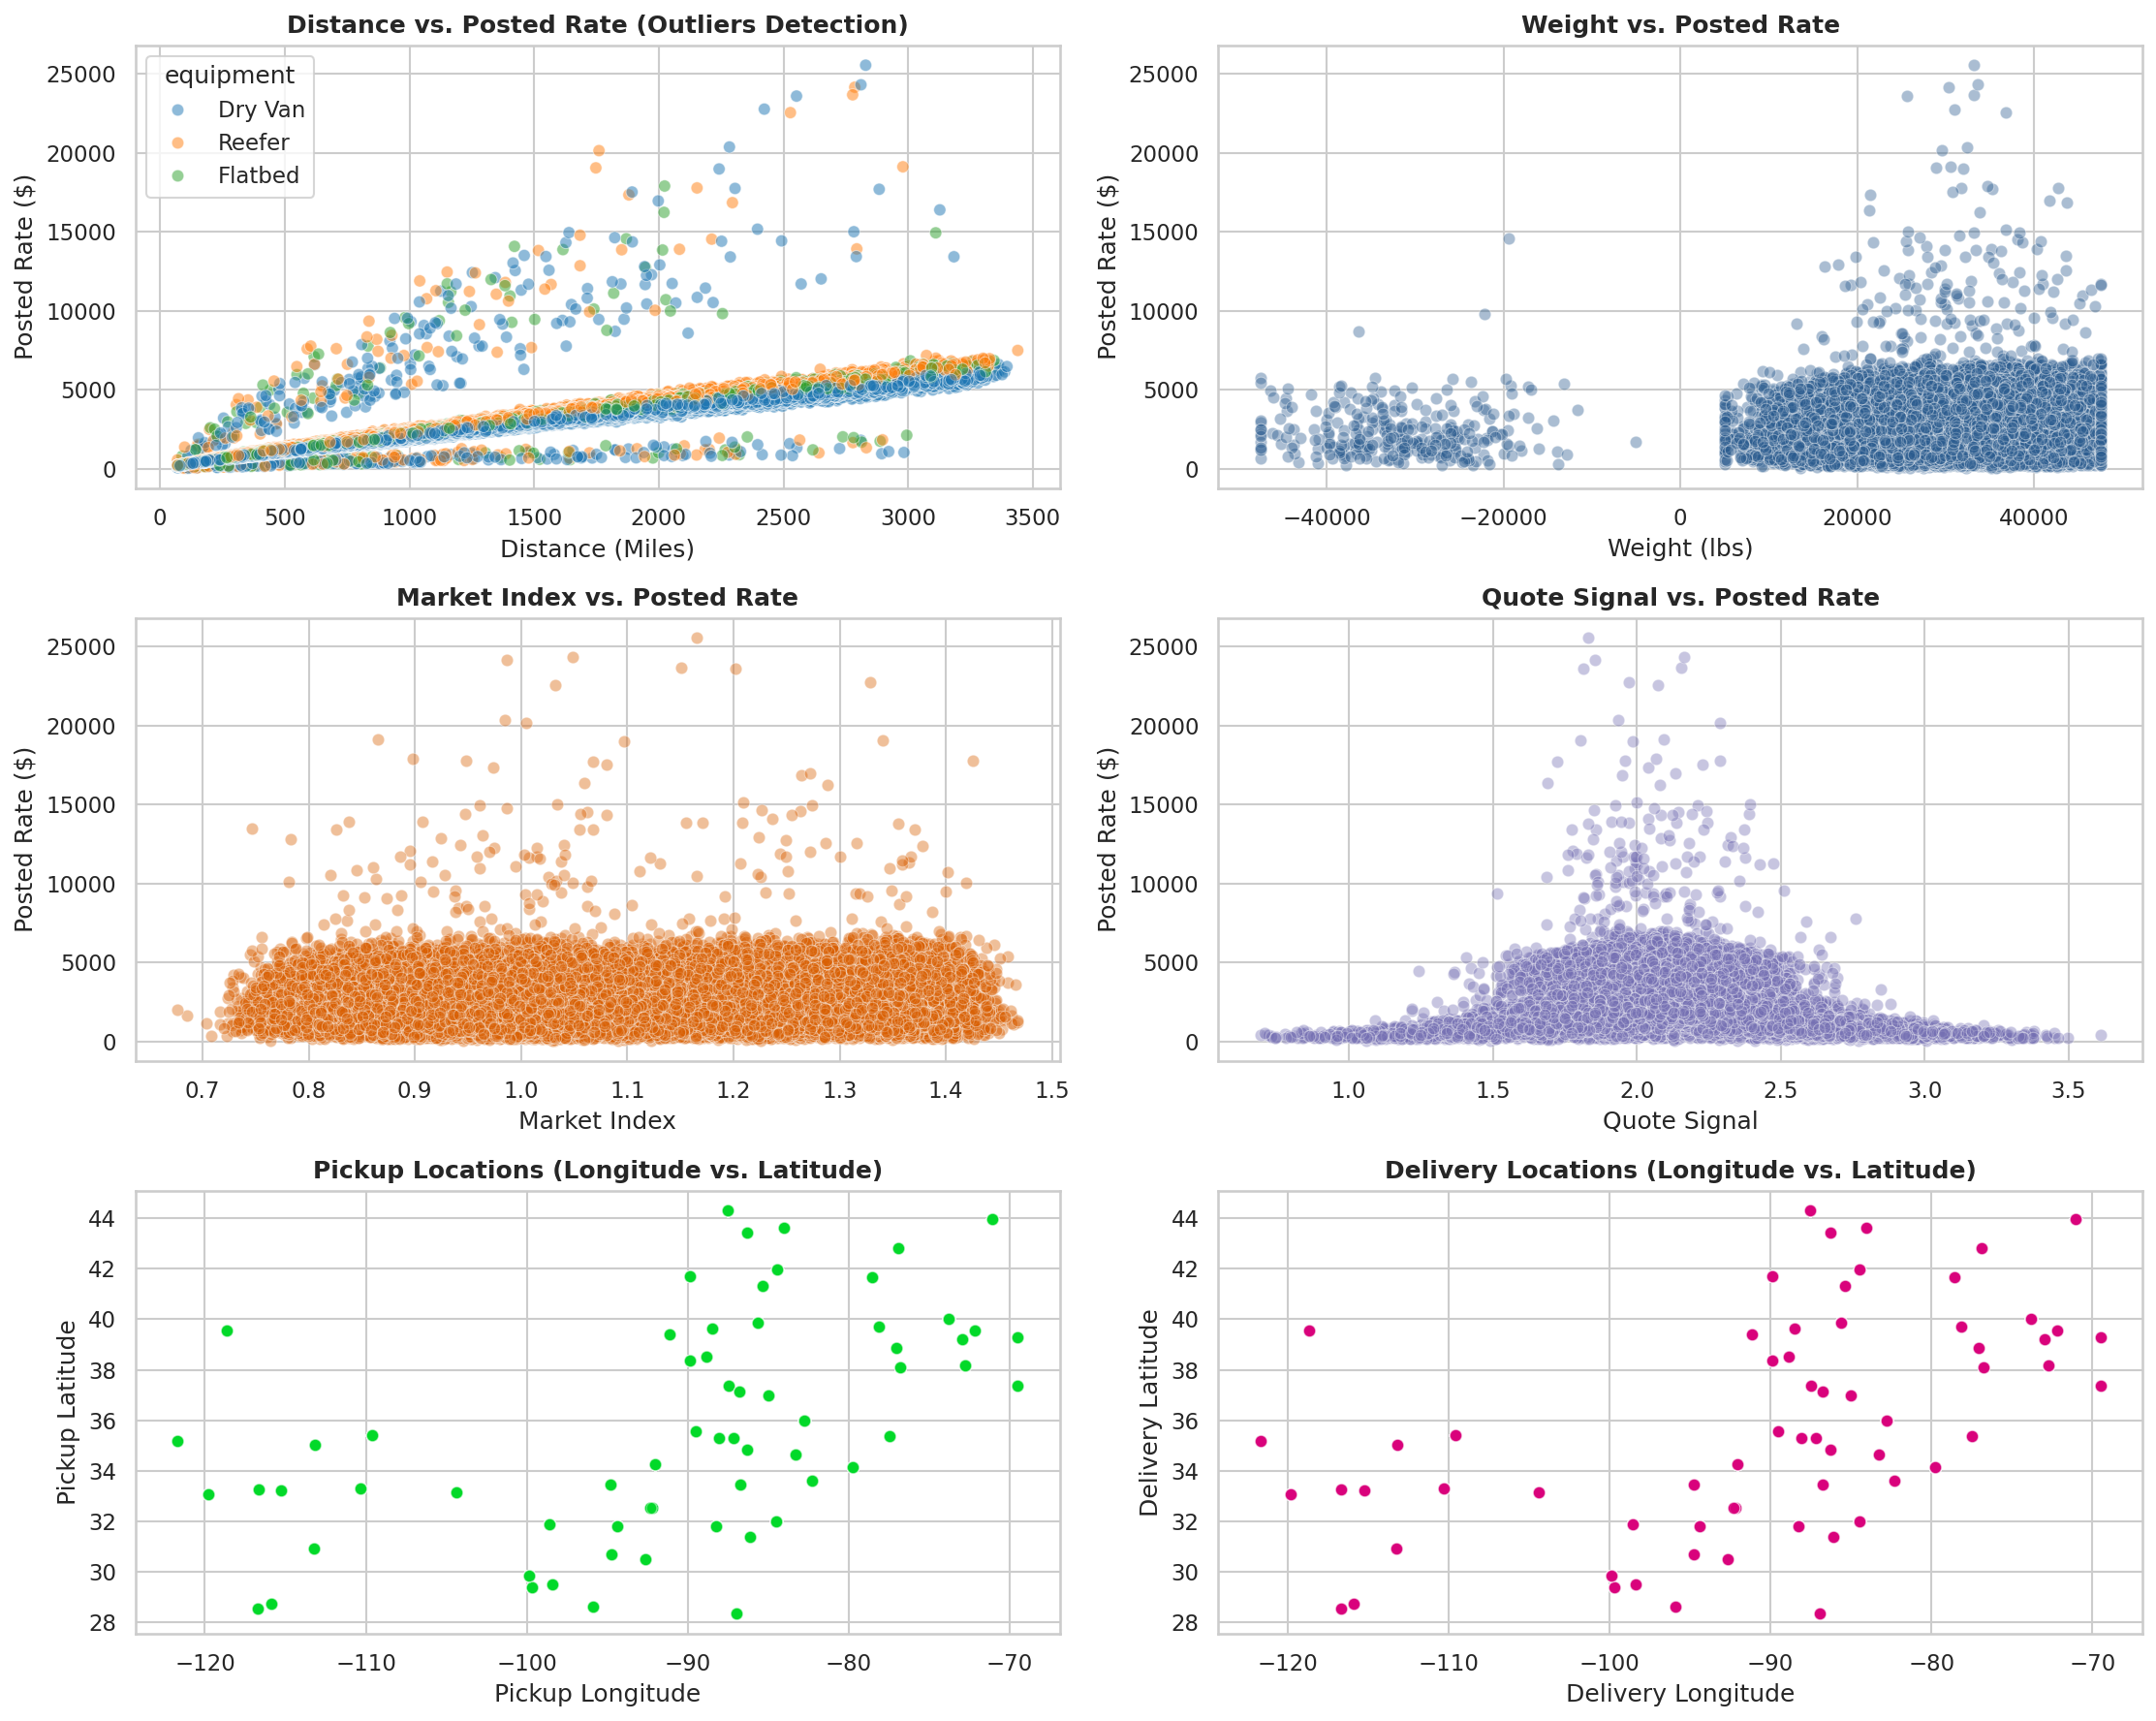

In [64]:
# 3. Scatter Plots for Relationship and Outlier Detection
fig, axes = plt.subplots(3, 2, figsize=(15, 12), dpi=150)

# Plot 1: Distance vs Posted Rate
sns.scatterplot(
    data=df, x='distance', y='posted_rate', hue='equipment', 
    alpha=0.5, ax=axes[0, 0], palette='tab10'
)
axes[0, 0].set_title("Distance vs. Posted Rate (Outliers Detection)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Distance (Miles)")
axes[0, 0].set_ylabel("Posted Rate ($)")

# Plot 2: Weight vs Posted Rate
sns.scatterplot(
    data=df, x='weight', y='posted_rate', 
    color='#2b5c8f', alpha=0.4, ax=axes[0, 1]
)
axes[0, 1].set_title("Weight vs. Posted Rate", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Weight (lbs)")
axes[0, 1].set_ylabel("Posted Rate ($)")

# Plot 3: Market Index vs Posted Rate
sns.scatterplot(
    data=df, x='market_index', y='posted_rate', 
    color='#d95f02', alpha=0.4, ax=axes[1, 0]
)
axes[1, 0].set_title("Market Index vs. Posted Rate", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Market Index")
axes[1, 0].set_ylabel("Posted Rate ($)")

# Plot 4: Quote Signal vs Posted Rate
sns.scatterplot(
    data=df, x='quote_signal', y='posted_rate', 
    color='#7570b3', alpha=0.4, ax=axes[1, 1]
)
axes[1, 1].set_title("Quote Signal vs. Posted Rate", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Quote Signal")
axes[1, 1].set_ylabel("Posted Rate ($)")

# Plot 5: pickup_lon vs pickup_lat
sns.scatterplot(
    data=df, x='pickup_lon', y='pickup_lat', 
    color='#02d929', alpha=0.4, ax=axes[2, 0]
)
axes[2, 0].set_title("Pickup Locations (Longitude vs. Latitude)", fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel("Pickup Longitude")
axes[2, 0].set_ylabel("Pickup Latitude")

# Plot 6: delivery_lon vs delivery_lat
sns.scatterplot(
    data=df, x='delivery_lon', y='delivery_lat', 
    color="#d9027c", alpha=0.5, ax=axes[2, 1]
)
axes[2, 1].set_title("Delivery Locations (Longitude vs. Latitude)", fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel("Delivery Longitude")
axes[2, 1].set_ylabel("Delivery Latitude")

plt.tight_layout()
plt.show()

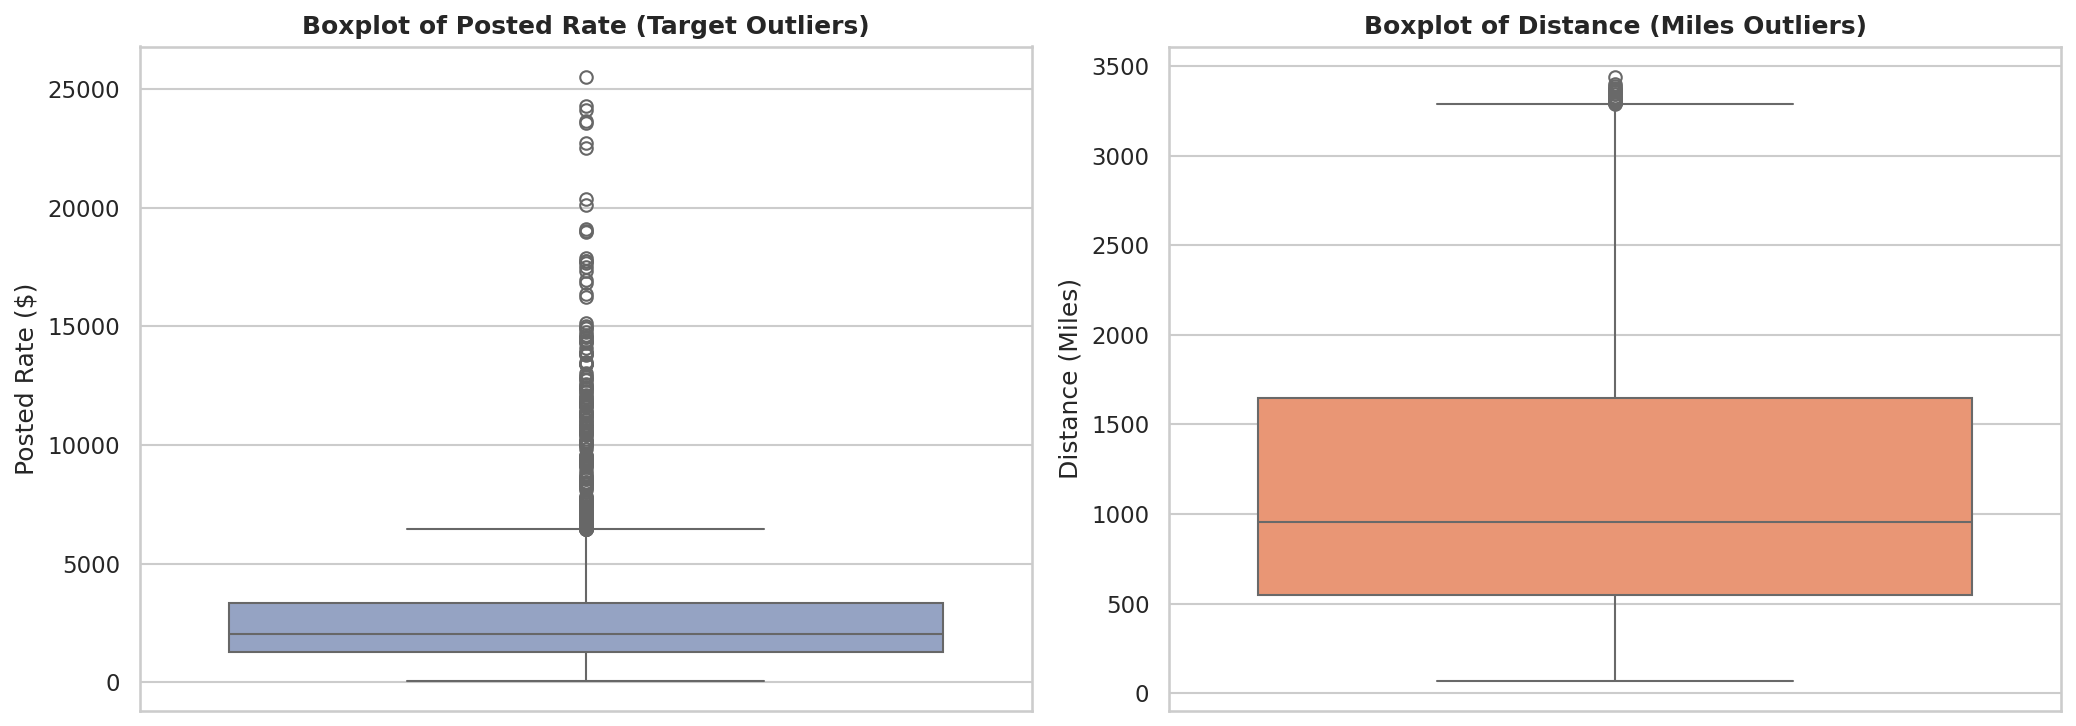

In [65]:
# 4. Check for Outliers Using Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Boxplot for posted_rate
sns.boxplot(y=df['posted_rate'], ax=axes[0], color='#8da0cb')
axes[0].set_title("Boxplot of Posted Rate (Target Outliers)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Posted Rate ($)")

# Boxplot for distance
sns.boxplot(y=df['distance'], ax=axes[1], color='#fc8d62')
axes[1].set_title("Boxplot of Distance (Miles Outliers)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Distance (Miles)")

plt.tight_layout()
plt.show()